### Poisson Green's Kernel: 1D with Dirichlet Boundary
Let $L = -\partial_{xx}$ and consider the Poisson problem
$$\begin{cases}
Lu(x) = f(x) & x \in (0,1)\\
u(x) = 0  & x\in \{0,1\}.
\end{cases}$$
Note that $$\phi_n(x) = \sqrt{2}\sin(n\pi x) \qquad \lambda_n = n^2 \pi^2 \qquad n \in \mathbb{N}$$
is an orthonormal eigenbasis for $L$. We therefore have that
$$
Lu(x) = f(x) \implies \sum_{n\in \mathbb{N}} u_n \phi_n(x) = \sum_{n\in \mathbb{N}} f_n(x)\phi_n(x) \implies u_n = \frac{f_n}{\lambda_n}
$$
Thus, 
$$u(x) = \sum_{n}\left(\frac{1}{\lambda_n}\int_0^1 f(y)\phi_n(y)dy\right)\phi_n(x) = \int_0^1\left[\sum_{n} \frac{\phi_n(x)\phi_n(y)}{\lambda_n}\right]f(y) dy  = \int_{0}^1 G(x,y)f(y)dy.$$
One can show that the Green's kernel
$$G(x,y) = \sum_{n} \frac{\phi_n(x)\phi_n(y)}{\lambda_n} = \min\{x,y\}-xy = \begin{cases} x(1-y) & x < y \\ y(x-1) & y<x \end{cases}$$

In [1]:
################################################################################################################
### Set Energy Threshhold 
################################################################################################################

import numpy as np

Sn = [0]
n = 0
tol = 1e-9
thresh = 0.995
def var(n):
    a = (n+1)**(2)
    return (1/(2*a + 3))
while True:
    term = var(n)
    if term > tol: 
        Sn.append(Sn[-1] + var(n))
        n+=1
    else:
        print(f"Partial Sum converges to within {tol:.1e} at mode {n}")
        break
Sn = np.array(Sn)

print(f"{thresh*100}% energy capturing mode: {np.argmin(np.abs(Sn - Sn[-1]*thresh))}")

Partial Sum converges to within 1.0e-09 at mode 22360
99.5% energy capturing mode: 208


In [1]:
################################################################################################################
### Import libraries:
################################################################################################################

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0,"../Modules/")
from Block_WLS import Block_WLS
from Tensor_InducedSamp import Jacobi_Tensor_Induced_Sampling
from jacobi_sampling import jacobi_tensor_samp

################################################################################################################
### Main Function:
################################################################################################################

def boch_err_and_rel_kernel_err(n, max_mode = 208):

    #-- Induced Flag
    Induced = True 

    #--- Truncate modes in input and output bases 
    modes = np.arange(1,max_mode + 1)
    output_mode_truncation = max_mode 

    #-- Jacobi params for input function sampling 
    jacobi_params = [ [mode**(2), mode**(2)] for mode in modes]

    #--- Define maximal index set
    idx_set =  np.zeros((n,modes.shape[0]))
    idx_set[:n,:n] = np.eye(n)
    N = idx_set.shape[0]             # Dimension of (effective) approximation space 

    M = int(6.5*N * np.log(4*N))     # Number of samples to take for training data 
    M_test = 500                     # Number of samples to take for testing data 

    #--- Define inverse Laplacian operator  
    operator_diag = [1/(n**2 * np.pi**2) for n in modes]

    #--- Generate Train and Test Data 
    
    def sample_input(M, idx_set, induced = True):
        """ 
        Sample train and test forcing function spectral coeffs via Induced and MC sampling, resp.
        """
        if induced == True: 
            return Jacobi_Tensor_Induced_Sampling(M,idx_set,jacobi_params, max_poly_degree=1)
        else: 
            return jacobi_tensor_samp(jacobi_params ,M)

    def apply_operator(f):
        return f * operator_diag

    input_samples = sample_input(M=M, idx_set=idx_set, induced=Induced)
    test_input_samples = sample_input(M = M_test, idx_set= idx_set, induced=False)

    #--- Apply to test and train samples
    output_samples = apply_operator(input_samples)
    test_output_samples = apply_operator(test_input_samples)

    #--- Instantiate the operator learning object.
    wls_operator = Block_WLS(jacobi_params, idx_set, input_samples, output_samples, induced = Induced)

    #--- Apply the operator to test data.
    test_approx_outputs = wls_operator.apply(test_input_samples)

    #--- Compute relative L2 error in output 
    test_boch = np.sqrt(np.mean(np.linalg.norm(test_approx_outputs - test_output_samples, axis = 1)**2))
    true_boch = np.sqrt(np.mean(np.linalg.norm(test_output_samples, axis = 1)**2))
    rel_boch_err = test_boch / true_boch

    #--- Dirichlet Green's function on (0,1) 
    def G_piecewise(x, y):
        """Vectorized closed form: min{x,y} - x*y."""
        x = np.asarray(x)
        y = np.asarray(y)
        return np.minimum(x, y) - x*y

    def G_approx(x,y,n):
        x = np.asarray(x)[..., None]     # (..., 1)
        y = np.asarray(y)[..., None]     # (..., 1)
        N = np.arange(1,output_mode_truncation+1)
        alpha = [float(jacobi_params[k][0]) for k in range(len(jacobi_params))]
        sigma_inv = (np.sqrt((2*np.array(alpha) + 3)**(-1)))**(-1)
        diag_coeffs = np.zeros(len(N))
        diag_coeffs[:n] = np.diag(wls_operator.C)*sigma_inv[:n]
        terms = diag_coeffs * np.sqrt(2)* np.sin(np.pi * N * x) * np.sqrt(2)*np.sin(np.pi * N * y)

        return np.sum(terms, axis=-1)


    def rel_L2_err(n):
        N = np.arange(1,output_mode_truncation+1)
        alpha = [float(jacobi_params[k][0]) for k in range(len(jacobi_params))]
        sigma_inv = (np.sqrt((2*np.array(alpha) + 3)**(-1)))**(-1)
        diag_coeffs = np.zeros(len(N))
        diag_coeffs[:n] = np.diag(wls_operator.C)*sigma_inv[:n]  
        terms = (1 / (N**2 * np.pi**2))
        err = np.sum((terms - diag_coeffs)**2, axis = -1) / np.sum(terms**2, axis = -1)
        return err

 
    dx = 500
    x = np.linspace(0.0, 1.0, dx)
    y = np.linspace(0.0, 1.0, dx)
    X, Y = np.meshgrid(x, y, indexing="xy")

    Z = G_piecewise(X,Y)
    Z_approx = G_approx(X, Y, n=n)
    Z_diff = np.abs(Z - Z_approx)

    return rel_boch_err, rel_L2_err(n = n), Z, Z_diff

################################################################################################################
### Loop and Plots
################################################################################################################

rel_boch_err = []
rel_kern_err = []
Zdiffs = []
ns = np.array([1] + list(np.arange(10,110,10)))
for n in ns:
    print(n)
    b_err, k_err, Z, Z_diff = boch_err_and_rel_kernel_err(n=n)
    rel_boch_err.append(b_err)
    rel_kern_err.append(k_err)
    Zdiffs.append(Z_diff)

np.save("data/ker_rel_boch_err.npy",rel_boch_err)
np.save("data/ker_rel_kern_err.npy",rel_kern_err)
np.save("Data/ker_Zdiffs.npy", Zdiffs)

1
10
20
30
40
50
60
70
80
90
100


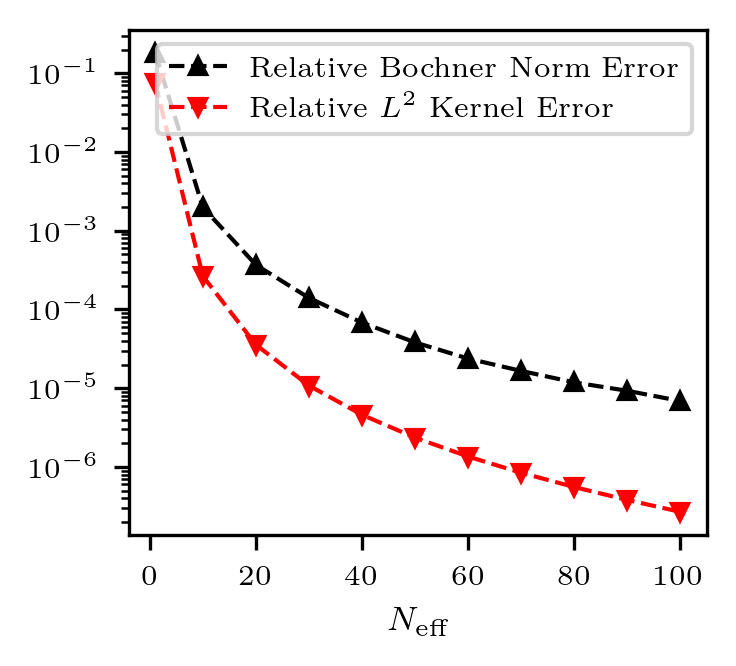

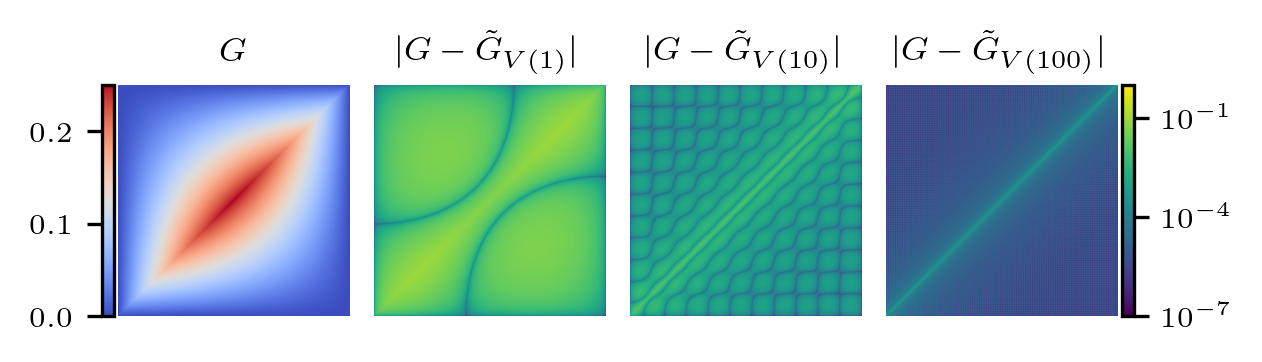

In [32]:
import matplotlib as mpl
import matplotlib.pyplot as plt
# General params 
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "Computer Modern"
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams['savefig.transparent'] = True
plt.rcParams["savefig.format"] = "pdf"
mpl.rcParams['figure.dpi'] = 300

mpl.rcParams["pdf.fonttype"] = 42   # TrueType
mpl.rcParams["ps.fonttype"] = 42

# Set figure sizes 
textwidth_pt = 422.52252                     
pt_to_inch = 1.0 / 72.27
subfig_ratio = 1.0
fig_width = textwidth_pt * pt_to_inch   *subfig_ratio         
fig_height = fig_width * 0.9                     
# Font sizes
base = 7  # match LaTeX \normalsize
plt.rcParams["font.size"] = base
plt.rcParams["axes.labelsize"] = base + 1      
plt.rcParams["axes.titlesize"] = base + 1      
plt.rcParams["xtick.labelsize"] = base         
plt.rcParams["ytick.labelsize"] = base         
plt.rcParams["legend.fontsize"] = base         
# Markersizes
markersize_small = 1
linewidth_small = 0.5
markersize_large = 4
linewidth_large = 1 


#--- Error Plot 
fig,ax = plt.subplots(figsize = (0.4*fig_width,0.4*fig_height), layout = 'constrained')
ax.plot(ns, rel_boch_err, '^--', color = 'k', label = "Relative Bochner Norm Error", markersize = markersize_large, linewidth = linewidth_large)
ax.plot(ns, rel_kern_err, 'v--', color = 'red', label = "Relative $L^2$ Kernel Error", markersize = markersize_large, linewidth = linewidth_large)
ax.set(xlabel = r"$N_{\mathrm{eff}}$", yscale='log')
ax.legend(loc = 'best')
#ax.set_title(r"Operator and Kernel Error for $\Lambda = \mathrm{TP}(k)$")
plt.savefig("Plots/rel_l2_kernel_and_boch_err.pdf", bbox_inches="tight")
plt.show()


#---Kernel Plot 
plot_modes = [0,1,10,50,100] #0 is a buffer to make indices more clear.
plot_idxs = [0,1,5,10]
Zdiffs = np.array(Zdiffs)
diffs = Zdiffs[plot_idxs]

from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, axes = plt.subplots(1, len(plot_idxs), figsize=(0.7*fig_width, 0.7*fig_height), layout = 'constrained')

im0 = axes[0].imshow(Z, origin='lower', extent=[0, 1, 0, 1], cmap='coolwarm')
cbar0 = fig.colorbar(im0, 
                     ax=axes[0],
                     location = 'left',
                     pad = 0.02, 
                     fraction = 0.05)
axes[0].set_title(r"$G$")

vmin = np.min(diffs)
vmax = np.max(diffs)
from matplotlib.colors import LogNorm
norm = LogNorm( 1e-7, 1)

im1 = axes[1].imshow(diffs[0], origin='lower', extent=[0, 1, 0, 1], cmap='viridis', norm = norm)
axes[1].set_title(r"$\vert G - \tilde{G}_{V(1)}\vert$")

im2 = axes[2].imshow(diffs[1], origin='lower', extent=[0, 1, 0, 1], cmap='viridis',  norm = norm)
axes[2].set_title(r"$\vert G - \tilde{G}_{V(10)}\vert$")

im3 = axes[3].imshow(diffs[3], origin='lower', extent=[0, 1, 0, 1], cmap='viridis', norm = norm)
axes[3].set_title(r"$\vert G - \tilde{G}_{V(100)} \vert $")

cbar3 = fig.colorbar(im3, 
                     ax=axes[3],
                     location = 'right',
                     pad = 0.02, 
                     fraction = 0.05)

for ax in axes:
    ax.axis('off')  
plt.savefig("Plots/kernel_pointwise_err.pdf", bbox_inches="tight")